# Deep-well injection & recovery on an unstructured grid

An aquifer storage-and-recovery (ASR) example: **oxic** water is injected into
a **2-layer, anoxic, pyrite-bearing** aquifer through an injection well, while
a nearby extraction well recovers water. This tutorial shows the
**transport-first** workflow end to end — build **one** ordinary MODFLOW 6
flow + transport model, run it **conservatively** first (a chloride tracer of
the injected water), then wrap that same model with
:meth:`~mf6rtm.mup3d.base.Mup3d.from_mf6` to add the reaction network and see
the sulfate that pyrite oxidation generates.

**Capabilities shown here:** transport-first coupling via ``from_mf6``; an
unstructured **DISV** grid refined around the wells; **two stress periods** with
the wells switching on and off; PHREEQC selected-output generated
**automatically — no postfix file**; and reactive results written to **HDF5**
(``sout.h5``).

## The reaction network

The driver is **kinetic pyrite oxidation**: where the injected oxygen reaches
the pyrite (FeS₂), it oxidises, consuming O₂ and releasing **sulfate**, iron
and acidity, roughly

> FeS₂ + 3.75 O₂ + 3.5 H₂O → Fe(OH)₃ + 2 SO₄²⁻ + 4 H⁺

Around it the model carries cation **exchange** (Ca/Fe/K/Mg/Na) and
**ferrihydrite** at equilibrium. Oxygen is consumed by **pyrite alone**, so all
the injected O₂ goes into producing sulfate. A conservative **chloride** tracer
maps where the injected water travels; the reactive run then shows the sulfate
that pyrite oxidation adds on top.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import flopy
from flopy.discretization import StructuredGrid, VertexGrid
from flopy.utils.gridgen import Gridgen

from mf6rtm import utils, mup3d

if os.path.isdir("data"):
    BASE = "."
else:
    BASE = os.path.join("docs", "tutorials")
DATA = os.path.join(BASE, "data")

## 1. Build a 2-layer quadtree DISV grid, refined around the wells

A 200 m × 200 m, 2-layer domain on a 20×20 base grid. An **injection well** and an
**extraction well** sit in the middle; the grid is refined around both. The
wells are screened in **layer 2** (the lower layer).

In [2]:
length_units = "meters"
time_units = "days"

Lx = Ly = 200.0
nlay, nrow, ncol = 2, 20, 20
delr = Lx / ncol
delc = Ly / nrow
top = 5.0
botm = [2.5, 0.0]

xy_in = (0.35 * Lx, 0.3 * Ly)   # injection well
xy_out = (0.65 * Lx, 0.6 * Ly)  # extraction well

cons_ws = os.path.join(BASE, "_tutorial04_conservative")  # conservative run
sim_ws = os.path.join(BASE, "_tutorial04_run")            # reactive run
gridgen_ws = os.path.join(cons_ws, "gridgen")
os.makedirs(gridgen_ws, exist_ok=True)

base_grid = StructuredGrid(
    delr=np.full(ncol, delr), delc=np.full(nrow, delc),
    top=np.full((nrow, ncol), top),
    botm=np.array([np.full((nrow, ncol), b) for b in botm]),
)
g = Gridgen(base_grid, model_ws=gridgen_ws, exe_name="gridgen")


def _square(cx, cy, r=8.0):
    return [[(cx - r, cy - r), (cx + r, cy - r), (cx + r, cy + r),
             (cx - r, cy + r), (cx - r, cy - r)]]


g.add_refinement_features([_square(*xy_in), _square(*xy_out)], "polygon", 2,
                          list(range(nlay)))
g.build(verbose=False)
disv_props = g.get_gridprops_disv()
ncpl = disv_props["ncpl"]
print(f"DISV grid: {ncpl} cells/layer x {nlay} layers")

grid = VertexGrid(**g.get_gridprops_vertexgrid())
xc = np.array(grid.xcellcenters)
yc = np.array(grid.ycellcenters)


def nearest_cell(px, py):
    return int(np.argmin((xc - px) ** 2 + (yc - py) ** 2))


c_in = nearest_cell(*xy_in)
c_out = nearest_cell(*xy_out)
# constant-head outer borders: west, north, east (south is no-flow). Corner cells
# are assigned to a single border (west > north > east) so none is listed twice.
west = np.where(xc < delr)[0]
north = np.setdiff1d(np.where(yc > Ly - delc)[0], west)
east = np.setdiff1d(np.where(xc > Lx - delr)[0], np.union1d(west, north))

DISV grid: 568 cells/layer x 2 layers


## 2. Flow, boundary conditions and solver

The run has two stress periods: in **period 1** (40 d) only the injection well
runs, building the oxic plume; in **period 2** (40 d) injection continues and the
extraction well switches on, drawing water back. Both wells are screened in
layer 2, within a constant-head frame — the west edge is held higher than the
north and east edges to impose a regional gradient (south is no-flow).

The transport solver tolerance matters here: concentrations are ~10⁻³–10⁻⁴
mol/L, so we set ``outer_dvclose`` accordingly (10⁻⁶). ``from_mf6`` clones the tracer GWT's
IMS onto every component, so these settings apply to all of them.

In [3]:
nper = 2
# P1 (40 d): injection only; P2 (40 d): injection + extraction.
tdis_rc = [(40.0, 5, 1.0), (40.0, 5, 1.0)]
qwell_in = 200.0   # m3/d, injection well (both periods)
qwell_out = -300   # m3/d, extraction well (period 2 only)

# Ambient (anoxic aquifer) water.
aq = pd.read_csv(os.path.join(DATA, "tut04_ic_aq_chem.csv")).set_index("var")["value"]

# Injected water: the same (low-sulfate) major-ion background as the aquifer but
# aerated — oxygen-rich and oxidised — a sensible ASR source water. Sulfate is left
# at the ambient value, so the conservative case stays flat and any reactive rise
# in sulfate is produced by pyrite oxidation. Charge is balanced by PHREEQC
# (add_charge_flag in section 6).
inject = aq.copy()
inject["O(0)"] = 5.19e-4    # dissolved O2 (~8 mg/L): the oxidant that drives pyrite oxidation
inject["pe"] = 4.0          # oxic
inject["S(-2)"] = 0.0       # no reduced sulfur
inject["C(-4)"] = 0.0       # no methane
inject["Fe(+2)"] = 0.0      # iron removed by treatment
inject["Fe(+3)"] = 0.0
inject["Cl"] = 1.0e-3       # raised chloride marks the injected water (a conservative tracer)
inject["Tmp"] = 0.025
cl_ambient = float(aq["Cl"])
cl_inject = float(inject["Cl"])

# stress-period data (shared by the conservative and reactive builds)
# per-border constant heads (set independently to drive a regional gradient)
head_west, head_north, head_east = 100.0, 5.0, 5.0
chd = ([[(lay, int(i)), head_west, None] for lay in range(nlay) for i in west]
       + [[(lay, int(i)), head_north, None] for lay in range(nlay) for i in north]
       + [[(lay, int(i)), head_east, None] for lay in range(nlay) for i in east])
# injection runs in both periods; extraction switches on in period 2 (rate 0 in
# period 1 keeps the extraction well inactive there).
welin = {0: [[(1, c_in), qwell_in, None]], 1: [[(1, c_in), qwell_in, None]]}
welout = {0: [[(1, c_out), 0.0]], 1: [[(1, c_out), qwell_out]]}


def gwt_ims(sim, filename):
    return flopy.mf6.ModflowIms(
        sim, linear_acceleration="bicgstab",
        outer_dvclose=1e-6, outer_maximum=100,
        inner_dvclose=1e-6, inner_maximum=100, filename=filename)

## 3. Build one flow + tracer transport model

A GWF flow model plus a single conservative tracer GWT that carries **chloride**:
the aquifer starts at the ambient chloride concentration and the injection well
adds water at the (raised) injected chloride. This is both the conservative model
(run next) and the template ``from_mf6`` clones per component (section 5).

In [4]:
sim = flopy.mf6.MFSimulation(sim_name="asr", sim_ws=cons_ws, exe_name="mf6")
flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=tdis_rc, time_units=time_units)

gwf = flopy.mf6.ModflowGwf(sim, modelname="gwf", save_flows=True)
ims = flopy.mf6.ModflowIms(sim, complexity="complex", linear_acceleration="CG",
                           filename="gwf.ims")
sim.register_ims_package(ims, [gwf.name])
flopy.mf6.ModflowGwfdisv(gwf, length_units=length_units, **disv_props)
flopy.mf6.ModflowGwfnpf(gwf, save_specific_discharge=True, save_saturation=True,
                        icelltype=0, k=1.0, filename="gwf.npf")
flopy.mf6.ModflowGwfic(gwf, strt=100.0, filename="gwf.ic")
flopy.mf6.ModflowGwfoc(gwf, head_filerecord="gwf.hds", budget_filerecord="gwf.cbb",
                       saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])

# fill the 'tracer' aux with chloride: ambient on the CHD edges, injected at welin
chd_c = [[cid, h, cl_ambient] for cid, h, _ in chd]
welin_c = {sp: [[cid, q, cl_inject] for cid, q, _ in recs]
           for sp, recs in welin.items()}
flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_c, auxiliary=["tracer"],
                        pname="chdin", filename="gwf.chdin.chd")
flopy.mf6.ModflowGwfwel(gwf, stress_period_data=welin_c, auxiliary=["tracer"],
                        pname="welin", filename="gwf.welin.wel")
flopy.mf6.ModflowGwfwel(gwf, stress_period_data=welout, pname="welout",
                        filename="gwf.welout.wel")

gwt = flopy.mf6.ModflowGwt(sim, modelname="tracer")
sim.register_ims_package(gwt_ims(sim, "tracer.ims"), ["tracer"])
flopy.mf6.ModflowGwtdisv(gwt, length_units=length_units, **disv_props)
flopy.mf6.ModflowGwtic(gwt, strt=cl_ambient, filename="tracer.ic")
flopy.mf6.ModflowGwtssm(gwt, sources=[["chdin", "aux", "tracer"],
                                      ["welin", "aux", "tracer"]], filename="tracer.ssm")
flopy.mf6.ModflowGwtadv(gwt, scheme="tvd")
flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=10.0, ath1=0.1, filename="tracer.dsp")
flopy.mf6.ModflowGwtmst(gwt, porosity=0.25, filename="tracer.mst")
flopy.mf6.ModflowGwtoc(gwt, concentration_filerecord="tracer.ucn",
                       saverecord=[("CONCENTRATION", "ALL")])
flopy.mf6.ModflowGwfgwt(sim, exgtype="GWF6-GWT6", exgmnamea="gwf",
                        exgmnameb="tracer", filename="tracer.gwfgwt")

package_name = tracer.gwfgwt
filename = tracer.gwfgwt
package_type = gwfgwt
model_or_simulation_package = simulation
simulation_name = asr


## 4. Run it conservatively (no reactions) and plot the chloride tracer

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_0...
  writing package tracer.gwfgwt...
  writing model gwf...
    writing model name file...
    writing package disv...
    writing package npf...
    writing package ic...
    writing package oc...
    writing package chdin...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 116 based on size of stress_period_data
    writing package welin...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package welout...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
  writing model tracer...
    writing model name file...
    writing package disv...
    writing package ic...
    writing package ssm...
    writing package adv...
    writing package dsp...
    writing package mst...
    writing packa

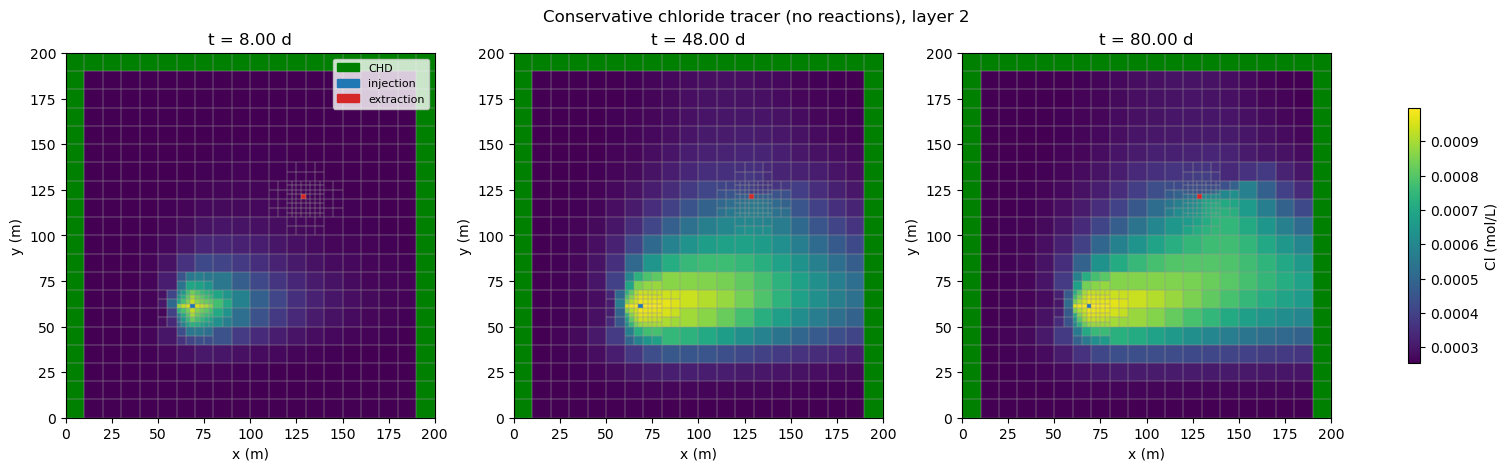

In [5]:
sim.write_simulation()
utils.prep_bins(cons_ws, src_path=os.path.join(BASE, "..", "..", "benchmark", "bin"))
sim.run_simulation(silent=True)


def panels(arrays, times, sup, clabel="mol/L"):
    vmax = max(np.nanmax(a) for a in arrays)
    vmin = min(np.nanmin(a) for a in arrays)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
    for ax, arr, t in zip(axs, arrays, times):
        full = np.full((nlay, ncpl), np.nan)
        full[1] = arr  # layer 2
        pmv = flopy.plot.PlotMapView(model=gwf, layer=1, ax=ax)
        im = pmv.plot_array(full, vmin=vmin, vmax=vmax)
        pmv.plot_grid(linewidth=0.2, color="0.6")
        pmv.plot_bc("chdin", color="green")
        pmv.plot_bc("welin", color="tab:blue")
        pmv.plot_bc("welout", color="tab:red")
        ax.set_title(f"t = {t:.2f} d")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
    handles = [Patch(color="green", label="CHD"),
               Patch(color="tab:blue", label="injection"),
               Patch(color="tab:red", label="extraction")]
    axs[0].legend(handles=handles, fontsize=8, loc="upper right")
    fig.colorbar(im, ax=axs, shrink=0.7, label=clabel)
    fig.suptitle(sup)
    plt.show()


ucn = flopy.utils.HeadFile(os.path.join(cons_ws, "tracer.ucn"), text="concentration")
ctimes = np.array(ucn.get_times())
csel = [ctimes[0], ctimes[len(ctimes) // 2], ctimes[-1]]
cons_arrays = [ucn.get_data(totim=t).reshape(nlay, ncpl)[1] for t in csel]
panels(cons_arrays, csel, "Conservative chloride tracer (no reactions), layer 2",
       clabel="Cl (mol/L)")

## 5. Geochemistry — the pyrite reaction network

The ambient (anoxic) water is read from the chemistry file and the injected
(oxic) water is defined above; cation exchange, equilibrium **ferrihydrite** and
kinetic **pyrite** complete the network (layer-1 values).

Pyrite dissolution uses the dissolved-oxygen rate law of Williamson & Rimstidt
(1994), parameterised after Appelo et al. (1998):

```
r_pyrite = 10^(-10.19) · (A/V) · (m/m0)^0.67 · [O2]^0.5 · [H+]^(-0.11) · f(T)
```

where `A/V` is the pyrite surface-area-to-water ratio, `m/m0` the remaining
mineral fraction and `f(T)` an Arrhenius temperature factor. The four
`parms=[16.0, 0.67, 0.5, -0.11]` set the surface-area term and the exponents on
`m/m0`, `[O2]` and `[H+]`; oxygen uptake is capped by the pyrite→sulfate
stoichiometry each step.

In [6]:
soldf = pd.DataFrame({1: aq, 2: inject})
soldf.index.name = "var"
soldf

,1,2
var,,
Orgc,1.663858e-05,0.000017
O(0),1.000000e-18,0.000519
C(+4),8.446000e-03,0.008446
C(-4),2.888620e-09,0.000000
Ca,2.061226e-03,0.002061
Cl,2.540000e-04,0.001000
Fe(+2),9.511595e-05,0.000000
Fe(+3),4.378765e-13,0.000000
K,1.341788e-04,0.000134


In [7]:
solution = mup3d.Solutions(utils.solution_df_to_dict(soldf))
solution.set_ic(np.ones((nlay, ncpl), dtype=float))

In [8]:
exdf = pd.read_csv(os.path.join(DATA, "tut04_ic_exchanger.csv"))
ex1 = exdf[exdf["layer"] == 1]
ex_names = {"Ca_ex": "CaX2", "Fe_ex": "FeX2", "K_ex": "KX",
            "Mg_ex": "MgX2", "Na_ex": "NaX"}
zone = {ex_names[r["var"]]: {"m0": float(r["value"])} for _, r in ex1.iterrows()}
exchanger = mup3d.ExchangePhases({0: zone})
exchanger.set_ic(np.ones((nlay, ncpl), dtype=float))
exchanger.set_equilibrate_solutions([1])

surf = pd.read_csv(os.path.join(DATA, "tut04_ic_surfaces.csv"))
s1 = surf[surf["layer"] == 1].set_index("var")["value"]
por = 0.35
fh = utils.concentration_volbulk_to_volwater(float(s1["Ferrihydrite"]), por)
equilibriums = mup3d.EquilibriumPhases(
    {1: {"Ferrihydrite": {"si": 0.0, "m0": fh}}})
equilibriums.set_ic(1)

# Pyrite is the only kinetic phase, so it is the sole sink for the injected oxygen.
py = utils.concentration_volbulk_to_volwater(float(s1["Pyrite"]), por)
kin = {1: {
    "Pyrite": {"m0": py, "parms": [16.0, 0.67, 0.5, -0.11]},
}}
kinetics = mup3d.KineticPhases(kin)
kinetics.set_ic(1)

## 6. Wrap the same model with `from_mf6` and run reactively

``from_mf6`` clones the tracer GWT into one reactive GWT per component. The CHD
edges carry the ambient anoxic water (solution 1) and the injection well the
oxic water (solution 2); the reactive run writes to a separate directory so the
conservative results are kept. No PHREEQC ``postfix`` is supplied — mf6rtm writes
a full selected-output (every solution total, phase and exchanger) automatically
— and here we store it as **HDF5** (``sout.h5``) via ``output_format="hdf5"``.

In [9]:
model = mup3d.Mup3d.from_mf6(sim, solution, name="asr", gwt_name="tracer")
model.set_wd(sim_ws)
model.set_database(os.path.join(DATA, "tut04_datab.dat"))
model.set_exchange_phases(exchanger)
model.set_phases(kinetics)
model.set_phases(equilibriums)
model.set_componenth2o(True)
model.initialize(add_charge_flag=True)  # balance solution charge on pH

cs_chd = mup3d.ChemStress("chdin", type="aux")
cs_chd.set_spd([1] * len(chd))    # ambient anoxic water on the CHD edges
model.set_chem_stress(cs_chd)
cs_wel = mup3d.ChemStress("welin", type="aux")
cs_wel.set_spd([2] * len(welin[0]))  # oxic injection water at the injection well
model.set_chem_stress(cs_wel)

model.write_simulation()
utils.prep_bins(model.wd, src_path=os.path.join(BASE, "..", "..", "benchmark", "bin"))
model.run(output_format="hdf5")  # write results to sout.h5 (needs PyTables)

Using temperatue of 25.0 for all cells
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Min concentration: None (no clipping)
  Reactions calculated at all time steps
Phreeqc initialized
Initializing ChemStress
ChemStress chdin initialized
Initializing ChemStress
ChemStress welin initialized


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_1...
  writing solution package ims_2...
  writing solution package ims_3...
  writing solution package ims_4...
  writing solution package ims_5...
  writing solution package ims_6...
  writing solution package ims_7...
  writing solution package ims_8...
  writing solution package ims_9...
  writing solution package ims_10...
  writing solution package ims_11...
  writing solution package ims_12...
  writing solution package ims_13...
  writing solution package ims_14...
  writing solution package ims_15...
  writing package H2O.gwfgwt...
  writing package H.gwfgwt...
  writing package O.gwfgwt...
  writing package Charge.gwfgwt...
  writing package C.gwfgwt...
  writing package Ca.gwfgwt...
  writing package Cl.gwfgwt...
  writing package Fe.gwfgwt...
  writing package K.gwfgwt...
  writing package Mg.gwfgwt...
  writing pac

    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model C...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Ca...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Cl...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Fe...
    writing model name file...
    writing package disv...
    writing package adv...
    writin

    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Mg...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Na...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Orgc...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model S...
    writing model name file...
    writing package disv...
    writing package adv...
    writ

    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
  writing model Tmp...
    writing model name file...
    writing package disv...
    writing package adv...
    writing package dsp...
    writing package ic...
    writing package mst...
    writing package ssm...
    writing package oc...
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Min concentration: None (no clipping)
  Reactions calculated at all time steps
Simulation saved in /Users/portega/dev/code/mf6rtm/mf6rtm-main/docs/tutorials/_tutorial04_run
Running mf6rtm


...

Reactions       | Stress period:  2     | Time step:      4          | Completed in :  0 min   3.55e-03 sec


Transport       | Stress period:  2     | Time step:      5          | Completed in :  0 min   1.33e-04 sec


Reactions       | Stress period:  2     | Time step:      5          | Completed in :  0 min   3.72e-03 sec



MODFLOW 6 converged successfully without any fails

MODEL RUN FINISHED BUT CHECK THE RESULTS

Solution finished at 2026-07-20 15:57:28. Running time:    0.10231 mins


True

## 7. Reactive results (layer 2)

With pyrite oxidation switched on: sulfate is produced where the injected oxygen
reaches the pyrite, dissolved oxygen is drawn down at that front, and chloride
still moves conservatively — matching the tracer run in section 4.

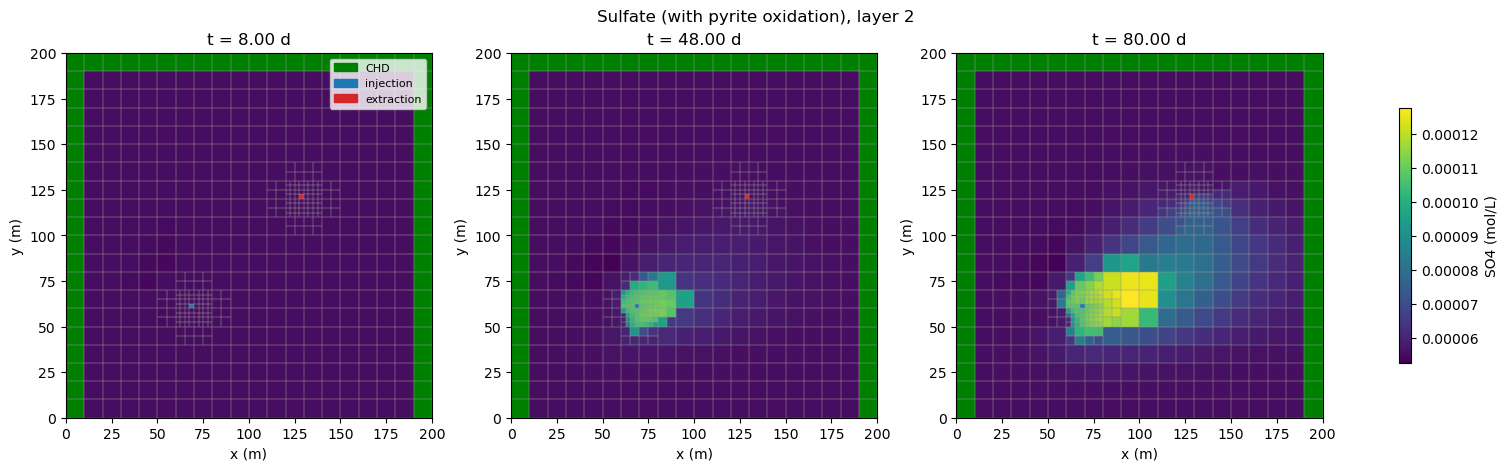

In [10]:
# mf6rtm's auto selected-output names each column
# ``solution_total_molality_<species>``; the spatial ``layer``/``cell2d`` columns
# make picking layer 2 straightforward.
sout = pd.read_hdf(os.path.join(model.wd, "sout.h5"), key="sout")
rtimes = np.sort(sout["time_d"].unique())
rsel = [rtimes[0], rtimes[len(rtimes) // 2], rtimes[-1]]


def layer2_arrays(col):
    """Layer-2 map of `col` at each selected time, indexed by cell2d."""
    out = []
    for t in rsel:
        lay2 = sout[(sout["time_d"] == t) & (sout["layer"] == 2)]
        arr = np.full(ncpl, np.nan)
        arr[lay2["cell2d"].astype(int).values - 1] = lay2[col].values
        out.append(arr)
    return out


panels(layer2_arrays("solution_total_molality_S(6)"), rsel,
       "Sulfate (with pyrite oxidation), layer 2", clabel="SO4 (mol/L)")

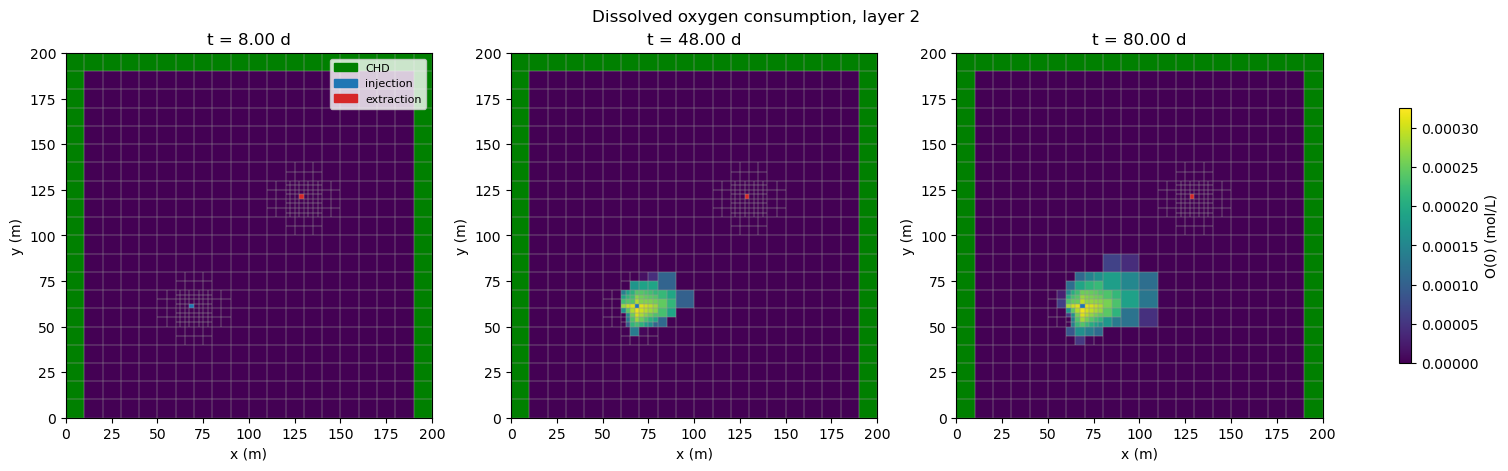

In [11]:
panels(layer2_arrays("solution_total_molality_O(0)"), rsel,
       "Dissolved oxygen consumption, layer 2", clabel="O(0) (mol/L)")

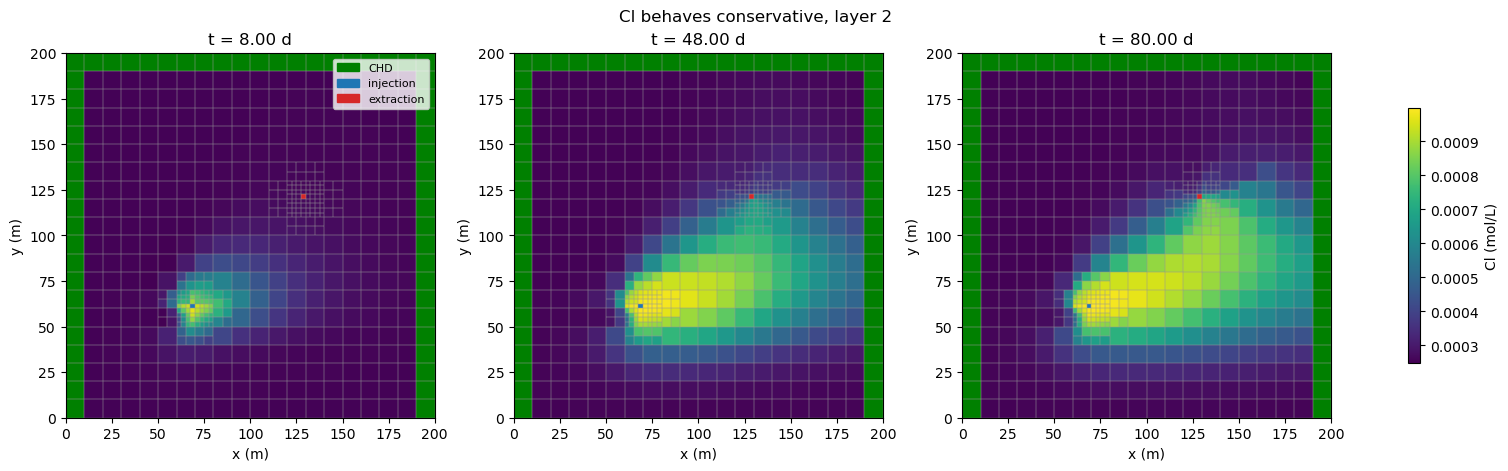

In [12]:
panels(layer2_arrays("solution_total_molality_Cl"), rsel,
       "Cl behaves conservative, layer 2", clabel="Cl (mol/L)")